# System Design Flow Verifier - Minimal LangGraph Skeleton

## Scenario
This notebook verifies and improves a textual system-design flow by sending it through specialized reviewer nodes for Security, Backend, and Performance. An Improver node applies the major comments, the workflow keeps conversation history in graph state, and a Human-in-the-Loop interruption is used before the final output.

## How agents communicate through state
The graph uses a shared state object so each node can read the current candidate flow and publish only its own delta. The three reviewer agents run in parallel, so the state intentionally separates append-only audit fields from the latest per-reviewer result map.

### State fields and what they contain
- `current_flow`: the candidate flow currently under review
- `conversation`: append-only audit log of what each node said or did
- `review_results`: latest result per reviewer for the current pass; each reviewer overwrites only its own key so parallel execution stays safe
- `improvement_log`: append-only record of applied recommendations
- `tool_traces`: append-only record of tool outputs used by nodes
- `loop_count`: number of automated improve-and-rerun cycles already used
- `last_human_message`: the latest revision note from the human reviewer
- `approval_status`: whether the current candidate is pending, approved, or rejected
- `final_output`: final summary prepared by the summarization node

### Which agent touches which fields
- Security, Backend, and Performance read `current_flow` and write `review_results`, `conversation`, and `tool_traces`
- The review router reads `review_results` and writes one audit message into `conversation`
- The Improver reads `current_flow`, `review_results`, and `last_human_message`, then writes `current_flow`, `improvement_log`, `conversation`, `loop_count`, `last_human_message`, and `approval_status`
- Human Review reads `current_flow`, `review_results`, and `loop_count`, then writes `approval_status`, `last_human_message`, and `conversation`
- Summarization reads the whole state history slice that matters for output and writes `final_output`, `conversation`, and `tool_traces`

## Scope for this iteration
This notebook implements the plan steps for reference extraction, notebook scaffolding, and a minimal working skeleton. The reviewer and summary behavior is rule-based for now so the LangGraph control flow, checkpoints, graph rendering, and interrupt/resume flow are easy to inspect.

## Reference patterns reused
- Interrupts notebook: interrupt, InMemorySaver, checkpoint inspection, state-history inspection, graph visualization helpers
- Simple Graphs Part 2: conditional routing in StateGraph
- Checkpointers Part 1: execution with thread-scoped checkpoints

In [1]:
%pip install -q langgraph langchain langchain-openai langchain-community python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_DIR = Path.cwd()
ENV_PATH = PROJECT_DIR / '.env'
load_dotenv(ENV_PATH, override=False)

print(f'Using environment file: {ENV_PATH}')
print(f'OPENAI_KEY present: {bool(os.getenv("OPENAI_KEY"))}')

Using environment file: d:\CodingProjects\SoftUniAgentWorkflows\LangGraph-simple-project\.env
OPENAI_KEY present: True


In [3]:
import logging
import operator
import sys
from datetime import datetime, timezone
from pprint import pformat
from typing import Annotated, TypedDict
from urllib.parse import quote_plus
from uuid import uuid4

from IPython.display import HTML, Image, display
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_core.tools import tool
from langgraph.checkpoint.base import BaseCheckpointSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command, Interrupt, interrupt

def merge_review_results(a: dict[str, dict[str, str] | None], b: dict[str, dict[str, str] | None]) -> dict[str, dict[str, str] | None]:
    return {**a, **b}

class UtcMillisFormatter(logging.Formatter):
    def formatTime(self, record, _datefmt=None):
        _ = _datefmt
        timestamp = datetime.fromtimestamp(record.created, timezone.utc)
        return timestamp.isoformat(timespec='milliseconds').replace('+00:00', 'Z')

logger = logging.getLogger('system_design_flow_verifier')
logger.setLevel(logging.INFO)
logger.handlers.clear()
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(UtcMillisFormatter('%(asctime)-24s --- %(message)s'))
logger.addHandler(stream_handler)
logger.propagate = False

def get_active_comments(state) -> list[dict[str, str]]:
    return [comment for comment in state.get('review_results', {}).values() if comment is not None]

def print_interrupts(interrupts: list[Interrupt]) -> None:
    for item in interrupts:
        display(HTML(f'<div style="border: 1px dashed red; margin: 5px; padding: 10px; white-space: pre-wrap;">{item.value}</div>'))

def display_graph(runnable: Runnable) -> None:
    try:
        display(Image(data=runnable.get_graph().draw_mermaid_png(), format='png'))
    except Exception as exc:
        logger.info(f'PNG graph rendering failed: {exc}')
        logger.info('ASCII fallback:')
        runnable.get_graph().print_ascii()

def explore_checkpoints(checkpointer: BaseCheckpointSaver, config: RunnableConfig) -> None:
    checkpoints = list(checkpointer.list(config))
    logger.info(f'There are {len(checkpoints)} checkpoints in total:')
    for checkpoint in reversed(checkpoints):
        for line in str(checkpoint).splitlines():
            logger.info(line)

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig) -> None:
    state_history = list(compiled_state_graph.get_state_history(config))
    for snapshot in reversed(state_history):
        logger.info(f"Step: {snapshot.metadata['step']}")
        logger.info('Current state:')
        for line in pformat(snapshot.values).splitlines():
            logger.info(line)
        logger.info(f'Next: {snapshot.next}')
        logger.info('')

def show_state(snapshot) -> None:
    logger.info(f'Interrupt count: {len(snapshot.interrupts)}')
    for line in pformat(snapshot.values).splitlines():
        logger.info(line)

In [ ]:
@tool
def search_reference(topic: str) -> str:
    """Return a minimal reference label for testing tool usage."""
    return f"reference:{topic.lower()}"

@tool
def youtube_search(query: str) -> str:
    """Return a YouTube search URL for testing the second tool path."""
    return f"https://www.youtube.com/results?search_query={quote_plus(query)}"

In [ ]:
class WorkflowState(TypedDict):
    current_flow: str
    conversation: Annotated[list[str], operator.add]
    review_results: Annotated[dict[str, dict[str, str] | None], merge_review_results]
    improvement_log: Annotated[list[str], operator.add]
    tool_traces: Annotated[list[str], operator.add]
    loop_count: int
    last_human_message: str
    approval_status: str
    final_output: str

In [ ]:
def build_comment(reviewer: str, rationale: str, recommendation: str, reference: str) -> dict[str, str]:
    return {
        'reviewer': reviewer,
        'rationale': rationale,
        'recommendation': recommendation,
        'reference': reference,
    }

def security_review(state: WorkflowState) -> dict:
    logger.info('[Security] node is executing')
    reference = search_reference.invoke({'topic': 'security'})
    flow = state['current_flow'].lower()

    if 'api gateway' in flow or 'authentication' in flow:
        return {
            'review_results': {'Security': None},
            'conversation': ['[Security] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Security',
        'The client reaches the service directly without an authentication and authorization boundary.',
        'Add an API Gateway before the Posts service and let it handle authentication and authorization.',
        reference,
    )
    return {
        'review_results': {'Security': comment},
        'conversation': [f"[Security] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def backend_review(state: WorkflowState) -> dict:
    logger.info('[Backend] node is executing')
    reference = search_reference.invoke({'topic': 'backend'})
    flow = state['current_flow'].lower()

    if 'outbox' in flow or ('database' in flow and 'broker' in flow and 'db first' in flow):
        return {
            'review_results': {'Backend': None},
            'conversation': ['[Backend] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Backend',
        'Publishing to the broker and writing to the database are not coordinated as one durable flow.',
        'Write to the database first and persist an outbox event in the same transaction before publishing to the broker.',
        reference,
    )
    return {
        'review_results': {'Backend': comment},
        'conversation': [f"[Backend] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def performance_review(state: WorkflowState) -> dict:
    logger.info('[Performance] node is executing')
    reference = search_reference.invoke({'topic': 'performance'})
    flow = state['current_flow'].lower()

    if 'asynchronously' in flow or 'acknowledge the client after the database commit' in flow:
        return {
            'review_results': {'Performance': None},
            'conversation': ['[Performance] No major comment.'],
            'tool_traces': [reference],
        }

    comment = build_comment(
        'Performance',
        'The flow keeps the client waiting for broker publication instead of acknowledging after durable write completion.',
        'Acknowledge the client after the database commit and publish the broker event asynchronously.',
        reference,
    )
    return {
        'review_results': {'Performance': comment},
        'conversation': [f"[Performance] {comment['recommendation']}"],
        'tool_traces': [reference],
    }

def review_router(state: WorkflowState) -> dict:
    active_comments = get_active_comments(state)
    logger.info(f'[Review Router] Active major comments: {len(active_comments)}')
    return {
        'conversation': [f'[Review Router] Active major comments: {len(active_comments)}'],
    }

In [ ]:
def improver(state: WorkflowState) -> dict:
    logger.info('[Improver] node is executing')
    recommendations = [comment['recommendation'] for comment in get_active_comments(state)]

    if state['last_human_message'].strip():
        recommendations.append(f"Human feedback: {state['last_human_message'].strip()}")

    updated_flow = state['current_flow'].strip()
    if recommendations:
        updated_flow += '\n\nImprovements applied:\n- ' + '\n- '.join(recommendations)

    summary = 'Applied improvements: ' + ('; '.join(recommendations) if recommendations else 'none')
    return {
        'current_flow': updated_flow,
        'improvement_log': recommendations,
        'conversation': [f'[Improver] {summary}'],
        'loop_count': state['loop_count'] + 1,
        'last_human_message': '',
        'approval_status': 'pending',
    }

def human_review(state: WorkflowState) -> dict:
    logger.info('[Human Review] node is executing')
    active_comments = get_active_comments(state)
    reason = 'Automated review reached the loop limit.' if active_comments else 'Automated review found no more major comments.'
    prompt = {
        'reason': reason,
        'loop_count': state['loop_count'],
        'current_flow': state['current_flow'],
        'pending_comments': active_comments,
        'question': 'Reply with {\'action\': \'approve\'} or {\'action\': \'reject\', \'feedback\': \'...\'}',
    }
    response = interrupt(prompt)

    if isinstance(response, str):
        response = {'action': 'reject', 'feedback': response}

    action = response.get('action', 'reject').lower()
    feedback = response.get('feedback', '').strip()

    if action == 'approve':
        approval_status = 'approved'
    elif action in {'reject', 'revise'}:
        approval_status = 'rejected'
    else:
        raise ValueError(f"Unsupported human review action: {action}")

    return {
        'approval_status': approval_status,
        'last_human_message': feedback,
        'conversation': [f"[Human] action={action}; feedback={feedback or 'No additional feedback.'}"],
    }

def summarize(state: WorkflowState) -> dict:
    logger.info('[Summarization] node is executing')
    youtube_links = [youtube_search.invoke(item) for item in state['improvement_log']]
    lines = [
        'Final flow proposal:',
        state['current_flow'],
        '',
        'Improvements made:',
    ]

    if state['improvement_log']:
        lines.extend([f'- {item}' for item in state['improvement_log']])
    else:
        lines.append('- No automated improvements were necessary.')

    if youtube_links:
        lines.append('')
        lines.append('YouTube references:')
        lines.extend([f'- {link}' for link in youtube_links])

    return {
        'final_output': '\n'.join(lines),
        'conversation': ['[Summarization] Final output prepared.'],
        'tool_traces': youtube_links,
    }

def route_after_reviews(state: WorkflowState) -> str:
    if not get_active_comments(state):
        return 'human_review'
    if state['loop_count'] < 2:
        return 'improver'
    return 'human_review'

def route_after_human_review(state: WorkflowState) -> str:
    if state['approval_status'] == 'approved':
        return 'summarize'
    elif state['approval_status'] == 'rejected':
        return 'improver'
    raise ValueError(f"Unsupported approval_status: {state['approval_status']}")

In [8]:
checkpointer = InMemorySaver()
graph_builder = StateGraph(WorkflowState)
graph_builder.add_node('security_review', security_review)
graph_builder.add_node('backend_review', backend_review)
graph_builder.add_node('performance_review', performance_review)
graph_builder.add_node('review_router', review_router)
graph_builder.add_node('improver', improver)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('summarize', summarize)

graph_builder.add_edge(START, 'security_review')
graph_builder.add_edge(START, 'backend_review')
graph_builder.add_edge(START, 'performance_review')
graph_builder.add_edge('security_review', 'review_router')
graph_builder.add_edge('backend_review', 'review_router')
graph_builder.add_edge('performance_review', 'review_router')
graph_builder.add_conditional_edges('review_router', route_after_reviews, ['improver', 'human_review'])
graph_builder.add_edge('improver', 'security_review')
graph_builder.add_edge('improver', 'backend_review')
graph_builder.add_edge('improver', 'performance_review')
graph_builder.add_conditional_edges('human_review', route_after_human_review, ['improver', 'summarize'])
graph_builder.add_edge('summarize', END)

graph = graph_builder.compile(checkpointer=checkpointer)

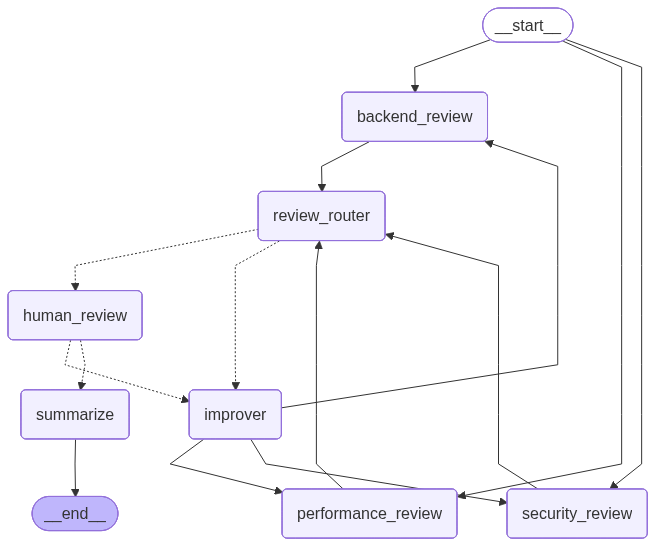

In [9]:
display_graph(graph)

In [ ]:
def execute_workflow(user_request: str, thread_id: str | None = None) -> dict:
    thread_id = thread_id or f'workflow-{uuid4()}'
    config = {'configurable': {'thread_id': thread_id}}
    initial_state: WorkflowState = {
        'current_flow': user_request,
        'conversation': [f'[User] {user_request}'],
        'review_results': {},
        'improvement_log': [],
        'tool_traces': [],
        'loop_count': 0,
        'last_human_message': '',
        'approval_status': 'pending',
        'final_output': '',
    }
    graph.invoke(initial_state, config=config)
    snapshot = graph.get_state(config)
    return {'config': config, 'snapshot': snapshot}

def resume_workflow(config: RunnableConfig, human_response: dict[str, str] | str) -> dict:
    graph.invoke(Command(resume=human_response), config=config)
    snapshot = graph.get_state(config)
    return {'config': config, 'snapshot': snapshot}

In [11]:
sample_flow = 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.'
run = execute_workflow(sample_flow, thread_id='sample-approval-path')
show_state(run['snapshot'])

2026-05-10T13:34:46.900Z --- [Backend] node is executing
2026-05-10T13:34:46.901Z --- [Performance] node is executing
2026-05-10T13:34:46.901Z --- [Security] node is executing
2026-05-10T13:34:46.901Z --- [Performance] node is executing
2026-05-10T13:34:46.901Z --- [Security] node is executing
2026-05-10T13:34:46.909Z --- [Review Router] Active major comments: 3
2026-05-10T13:34:46.910Z --- [Improver] node is executing
2026-05-10T13:34:46.913Z --- [Backend] node is executing
2026-05-10T13:34:46.914Z --- [Performance] node is executing
2026-05-10T13:34:46.914Z --- [Security] node is executing
2026-05-10T13:34:46.919Z --- [Review Router] Active major comments: 0
2026-05-10T13:34:46.921Z --- [Human Review] node is executing
2026-05-10T13:34:46.922Z --- Interrupt count: 1
2026-05-10T13:34:46.924Z --- {'approval_status': 'pending',
2026-05-10T13:34:46.925Z ---  'conversation': ['[User] Client send request to Posts service which sends a '
2026-05-10T13:34:46.925Z ---                   'messa

In [12]:
print_interrupts(run['snapshot'].interrupts)
explore_checkpoints(checkpointer, run['config'])
explore_state_history(graph, run['config'])

2026-05-10T13:34:46.982Z --- There are 7 checkpoints in total:
2026-05-10T13:34:46.984Z --- CheckpointTuple(config={'configurable': {'thread_id': 'sample-approval-path', 'checkpoint_ns': '', 'checkpoint_id': '1f14c750-2ea3-6e0d-bfff-abcc2a6f2856'}}, checkpoint={'v': 4, 'ts': '2026-05-10T13:34:46.898638+00:00', 'id': '1f14c750-2ea3-6e0d-bfff-abcc2a6f2856', 'channel_versions': {'__start__': '00000000000000000000000000000001.0.41873201894954404'}, 'versions_seen': {'__input__': {}}, 'updated_channels': ['__start__'], 'channel_values': {'__start__': {'user_request': 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.', 'original_flow': 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.', 'current_flow': 'Client send request to Posts service which sends a message to message broker and writes in the DB the respective new post.', 'conversation': ['[U

In [13]:
approved = resume_workflow(run['config'], {'action': 'approve'})
show_state(approved['snapshot'])
print(approved['snapshot'].values['final_output'])

2026-05-10T13:34:47.384Z --- [Human Review] node is executing
2026-05-10T13:34:47.387Z --- [Summarization] node is executing
2026-05-10T13:34:47.389Z --- Interrupt count: 0
2026-05-10T13:34:47.391Z --- {'approval_status': 'approved',
2026-05-10T13:34:47.392Z ---  'conversation': ['[User] Client send request to Posts service which sends a '
2026-05-10T13:34:47.392Z ---                   'message to message broker and writes in the DB the '
2026-05-10T13:34:47.393Z ---                   'respective new post.',
2026-05-10T13:34:47.393Z ---                   '[Backend] Write to the database first and persist an outbox '
2026-05-10T13:34:47.393Z ---                   'event in the same transaction before publishing to the '
2026-05-10T13:34:47.393Z ---                   'broker.',
2026-05-10T13:34:47.393Z ---                   '[Performance] Acknowledge the client after the database '
2026-05-10T13:34:47.393Z ---                   'commit and publish the broker event asynchronously.',
2026-